## 🏡 Predicting House Prices: A Comparison of Linear Regression and Random Forest 📊

<div style="background-color:#E8F4FF; padding:15px; border-radius:10px; border-left:6px solid #2F80ED"> 

<strong>📌 Project Introduction</strong>

Accurate house price prediction is essential for real estate decision-making, property valuation, and investment planning. This project analyses a housing dataset stored in Azure Blob Storage to identify the key factors influencing house prices and to develop predictive models for estimating property values.
<br><br>
Using Exploratory Data Analysis (EDA) and machine learning techniques, the project evaluates how features such as house size, number of bedrooms, and location characteristics impact price. The goal is to build a reliable and interpretable model by comparing different modelling approaches, including **Multiple Linear Regression** and **Random Forest.**

<br><br>

<strong>📊 Dataset Overview</strong>

The dataset includes the following features:

- <b>Square_Feet:</b> Total area of the house in square feet  
- <b>Num_Bedrooms:</b> Number of bedrooms  
- <b>Num_Bathrooms:</b> Number of bathrooms  
- <b>Num_Floors:</b> Number of floors  
- <b>Garage_Size:</b> Size of the garage  
- <b>Location_Score:</b> Desirability score of the location  
- <b>Distance_to_Center:</b> Distance (in km) to the city center  
- <b>Price:</b> House price (target variable)  

</div>


##  1️⃣ Load and Understand the Data

This step focuses on loading the dataset into a Pandas DataFrame and understanding its structure.

In [1]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage credentials
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

# 1️⃣.1️⃣ Connect to Azure Blob Storage
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the blob file
blob_client = blob_service_client.get_blob_client(container=container_name, blob=blob_name)

# Download and read the CSV file
blob_data = blob_client.download_blob().readall().decode("utf-8")

# 1️⃣.2️⃣ Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage
df_house_price = pd.read_csv(StringIO(blob_data))

# 1️⃣.3️⃣ Display table view
display(df_house_price.head())

# 1️⃣.4️⃣ Check data types and null values
df_house_price.info()
df_house_price.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Square_Feet         500 non-null    float64
 1   Num_Bedrooms        500 non-null    int64  
 2   Num_Bathrooms       500 non-null    int64  
 3   Num_Floors          500 non-null    int64  
 4   Garage_Size         500 non-null    int64  
 5   Location_Score      500 non-null    float64
 6   Distance_to_Center  500 non-null    float64
 7   Price               500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

#### 🔎Data Interpretation: 
<div style="background-color: #ead7cfff">

- Dataset contains **500 records and 8 features**
- All variables are **numerical**
- No major data quality issues detected
<br>
➡️ Next Step
Perform **Exploratory Data Analysis (EDA)** to understand patterns and relationships.
</div>

##  2️⃣ Exploratory Data Analysis (EDA) 

This step performs Exploratory Data Analysis (EDA) to understand the relationships between features and the target variable (Price).

In [ ]:
#installing seaborn library
%pip install seaborn

In [3]:
# Check summary statistics for the dataset
df_house_price.describe()

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.640428,2.958000,1.976000,1.964000,30.174000,5.164410,10.469641,582209.629531
std,74.672102,1.440968,0.820225,0.802491,11.582575,2.853489,5.588197,122273.390347
min,51.265396,1.000000,1.000000,1.000000,10.000000,0.004428,0.062818,276892.470100
25%,110.319923,2.000000,1.000000,1.000000,20.000000,2.760650,6.066754,503080.344175
50%,178.290937,3.000000,2.000000,2.000000,30.000000,5.206518,10.886066,574724.113350
75%,239.031220,4.000000,3.000000,3.000000,41.000000,7.732933,15.072590,665942.301300
max,298.241199,5.000000,3.000000,3.000000,49.000000,9.995439,19.927966,960678.274300


#### 🔎 key Insights:
<div style="background-color: #ead7cfff">

- The dataset contains 500 housing records and 8 variables.
- House prices range from ~$277k to ~$961k, showing significant variation.
- Average house price ≈ **$582k**
- The mean and median price are close, suggesting the distribution is relatively balanced.
- The dataset contains diverse housing characteristics, which is useful for predictive modelling.

<br> ➡️ Next Step is to Visualise relationships between features and price.
</div>

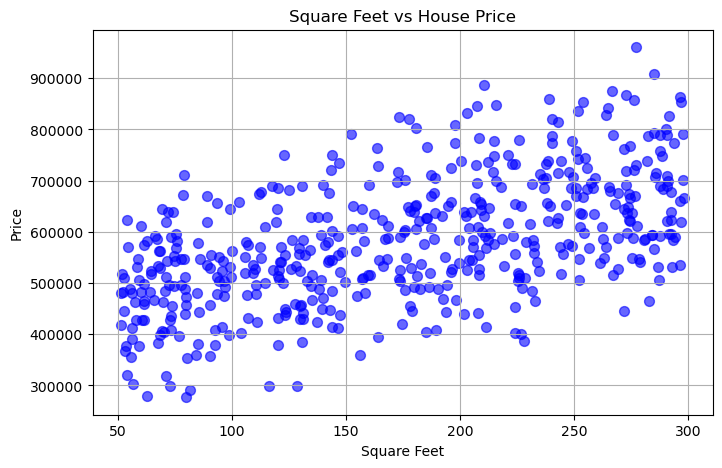

In [4]:
#Visualise the relationship between Square Feet and Price using a scatter plot
## 📈 Relationship Between Size and Price

# Import visualization libraries for data exploration and plotting
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))
plt.scatter(
    df_house_price["Square_Feet"], 
    df_house_price["Price"], 
    color='blue',   # color of points
    s=50,           # size of points
    alpha=0.6       # transparency to see overlapping points
)
plt.title("Square Feet vs House Price")
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.grid(True)
plt.show()


#### 🔎Key Insights: 

<div style="background-color: #ead7cfff">

- The scatter plot shows a clear upward trend between square footage and house price.
- There is a positive relationship between house size and price.
- Larger houses generally cost more than smaller houses.
- The spread of points suggests other variables also influence price, such as:
number of bedrooms
location
house features.
- This indicates Square_Feet is an important predictor of house price.
<br> ➡️ Next Step
Examine how house prices are distributed.
</div>


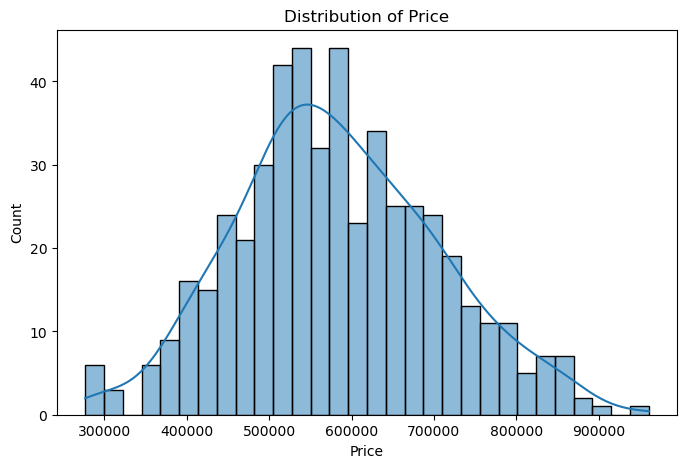

In [5]:
# Visualise the distribution of the Price variable using a histogram
plt.figure(figsize=(8,5))
sns.histplot(df_house_price["Price"], bins=30, kde=True)
plt.title("Distribution of Price")
plt.show()



<div style="background-color: #ead7cfff">
<strong> Data Interpretation: </strong>
<br>
- Prices follow an **approximately normal distribution**
- Most houses fall between **$500k–$700k**

➡️ Next Step
Check for outliers that may affect model performance.
</div>

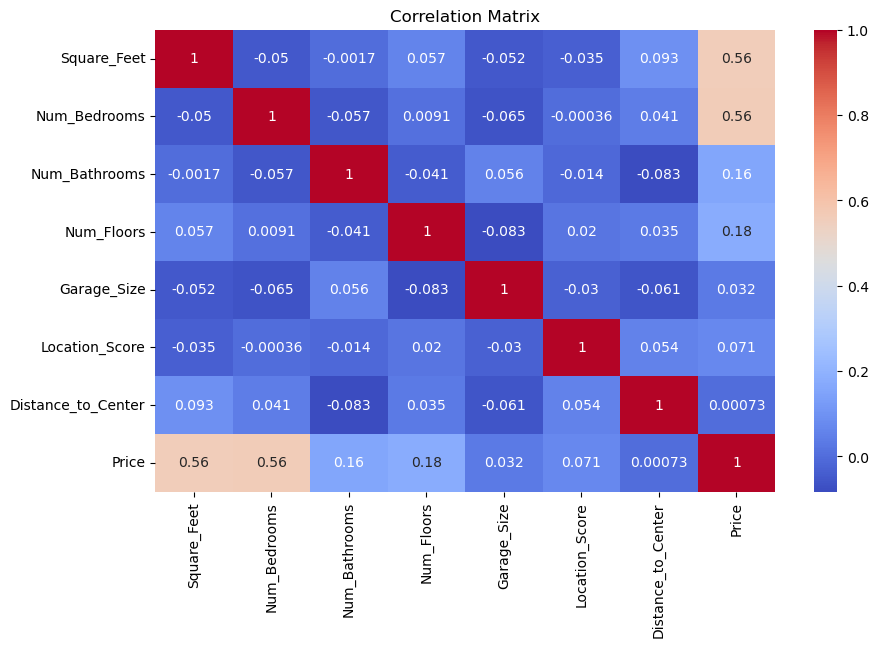

In [5]:
# Compute and visualize the correlation matrix between the features

plt.figure(figsize=(10,6))
sns.heatmap(df_house_price.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

<div style="background-color: #ead7cfff">
<strong> Data Interpretation: </strong>
<br>

Strongest predictors are: **Square_Feet** and **Num_Bedrooms**
</div>

## 3️⃣ Creating a Multiple Linear Regression (MLR) Model

In this step,  Multiple Linear Regression is used predict the Price of the house based on the features.The data is split into a training set and a testing set for fitting the model and evaluating its performance.



#### Creating a Multiple Linear Regression (MLR) Model 

In [6]:
# -----------------------------
# Multiple Linear Regression Model
# -----------------------------
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Split data into features/target and training/testing sets
X = df_house_price.drop("Price", axis=1)
y = df_house_price["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X.head())
print(y.head())

   Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Garage_Size  \
0   143.635030             1              3           3           48   
1   287.678577             1              2           1           37   
2   232.998485             1              3           2           14   
3   199.664621             5              2           2           17   
4    89.004660             4              3           3           34   

   Location_Score  Distance_to_Center  
0        8.297631            5.935734  
1        6.061466           10.827392  
2        2.911442            6.904599  
3        2.070949            8.284019  
4        1.523278           14.648277  
0    602134.8167
1    591425.1354
2    464478.6969
3    583105.6560
4    619879.1425
Name: Price, dtype: float64


In [8]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

🏃 View run dreamy_garage_b4ykjmng at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/c495e46c-d034-4742-9f10-70f5429e9ebb/workloads/ML/ML/Automatic/workspaceid/3ea99343-ea88-4485-84f7-16ccdde6599f/#/experiments/17cb5111-8536-40ab-b992-1134f1c3c949/runs/55ffa222-e593-44b8-a665-3f26de0dbcf1
🧪 View experiment at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/c495e46c-d034-4742-9f10-70f5429e9ebb/workloads/ML/ML/Automatic/workspaceid/3ea99343-ea88-4485-84f7-16ccdde6599f/#/experiments/17cb5111-8536-40ab-b992-1134f1c3c949


(400, 7) (100, 7) (400,) (100,)


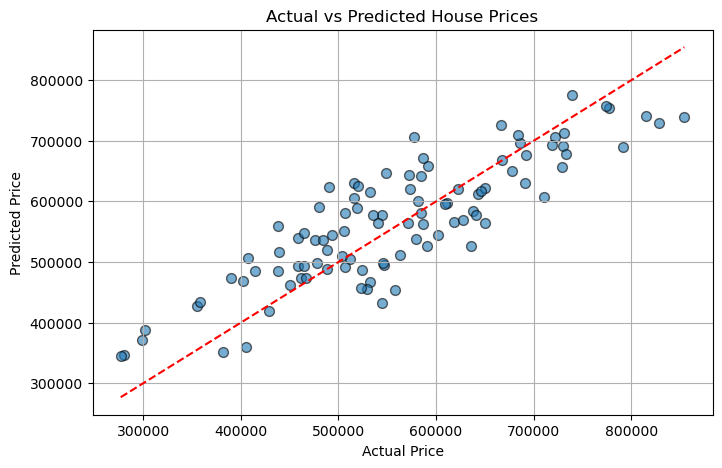

In [9]:
# Predict and visualize

y_pred = model.predict(X_test)
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, s=50, alpha=0.6, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()


In [10]:
# Evaluate the performance of the Multiple Linear Regression model.

# RMSE (Root Mean Squared Error) measures the average prediction error,
# while R² (coefficient of determination) indicates how well the model
# explains the variance in the house prices.
rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = model.score(X_test, y_test)
print("RMSE:", rmse_mlr)
print("R² score:", r2)

RMSE: 63952.37599755184
R² score: 0.7280979164789855


## 4️⃣ Compare with Random Forest Regressor 
In this section, a Random Forest Regressor model is trained and its performance is evaluated.
Actual vs predicted prices is visualized, and then its performance vs MLR is compared using Mean Squared_Error. 


🏃 View run calm_dolphin_fcbv1k3b at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/c495e46c-d034-4742-9f10-70f5429e9ebb/workloads/ML/ML/Automatic/workspaceid/3ea99343-ea88-4485-84f7-16ccdde6599f/#/experiments/17cb5111-8536-40ab-b992-1134f1c3c949/runs/c47cd708-4b7e-487b-82cf-a04b973bc5f8
🧪 View experiment at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/c495e46c-d034-4742-9f10-70f5429e9ebb/workloads/ML/ML/Automatic/workspaceid/3ea99343-ea88-4485-84f7-16ccdde6599f/#/experiments/17cb5111-8536-40ab-b992-1134f1c3c949


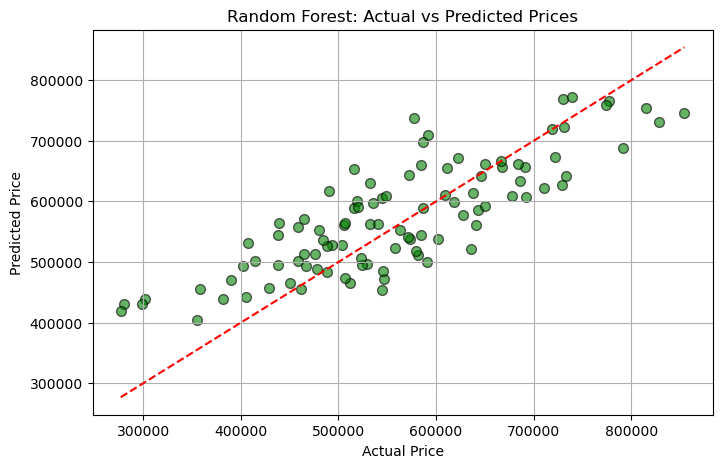

MLR RMSE: 63952.37599755184
Random Forest RMSE: 71733.35944826744
MLR performs better than Random Forest.


In [11]:
# -----------------------------
# Random Forest Regressor
# -----------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Visualise Actual vs Predicted Prices
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, s=50, alpha=0.6, edgecolor='black', color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.grid(True)
plt.show()

# Compare RMSE with MLR
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("MLR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))  # from Step 3
print("Random Forest RMSE:", rmse_rf)

if rmse_rf < rmse_mlr:
    print("Random Forest performs better than MLR.")
else:
    print("MLR performs better than Random Forest.")

## 5️⃣ Conclusion and Insights 


🔎 Key Insights:
- Square_Feet and Num_Bedrooms are the strongest predictors of Price.,
- Multiple Linear Regression is the best-performing model.,
- Random Forest did not improve prediction accuracy in this dataset.,
-  Additional variables may improve future model performance.

📊 Better Performing Model:
   - Random Forest performs is better based on RMSE.

🔨 Suggested Improvements:

- Add more relevant features such as house age, neighborhood quality, and condition.,
- Perform feature engineering and interaction terms for MLR.,
- Check for outliers and influential observations.

<div style="background-color:#F3F9F6; padding:18px; border-radius:10px; border-left:6px solid #27AE60">

<h2 style="color:#27AE60">📌 Final Conclusion</h2>

This project demonstrates that house prices can be predicted effectively using the available housing features. Exploratory Data Analysis (EDA) revealed that <b>Square_Feet</b> and <b>Num_Bedrooms</b> are the strongest drivers of house price. Among the models tested, <b>Multiple Linear Regression outperformed the Random Forest Regressor</b>, achieving a lower RMSE and higher R².

<br>
These results suggest that the relationship between the predictors and house price is largely <b>linear</b> in this dataset. While the regression model provides a strong and interpretable baseline for price prediction, the Random Forest model may benefit from adjusting its model settings, incorporating additional features, and using a larger dataset to capture more complex relationships in future analyses.

</div>